In [ ]:
python_workflow = {1: 'Collect Data', 
                   2: 'Build Model', 
                   3: 'Training',
                   4: 'Evaluation and Testing', 
                   5: 'Saving and Load Model',
                   6: 'Putting it all Together'
                   }

In [2]:
python_workflow

{1: 'Collect Data',
 2: 'Build Model',
 3: 'Training',
 4: 'Evaluation and Testing',
 5: 'Saving and Load Model',
 6: 'Putting it all Together'}

In [3]:
import torch 
from torch import nn 
import matplotlib.pyplot as plt 

In [ ]:
torch.__version__

'2.9.0+cu128'

### LINEAR REGRESSION 
- (f(x) = WX + b)

In [5]:
weight = 0.5
bias = 0.3
X = torch.arange(start=1, end= 100, step=5)
X, X.shape

(tensor([ 1,  6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 81, 86,
         91, 96]),
 torch.Size([20]))

In [6]:
X = X.unsqueeze(dim=1)
X, X.shape

(tensor([[ 1],
         [ 6],
         [11],
         [16],
         [21],
         [26],
         [31],
         [36],
         [41],
         [46],
         [51],
         [56],
         [61],
         [66],
         [71],
         [76],
         [81],
         [86],
         [91],
         [96]]),
 torch.Size([20, 1]))

In [7]:
# linear regression 
y = weight*X + bias
y

tensor([[ 0.8000],
        [ 3.3000],
        [ 5.8000],
        [ 8.3000],
        [10.8000],
        [13.3000],
        [15.8000],
        [18.3000],
        [20.8000],
        [23.3000],
        [25.8000],
        [28.3000],
        [30.8000],
        [33.3000],
        [35.8000],
        [38.3000],
        [40.8000],
        [43.3000],
        [45.8000],
        [48.3000]])

### Splitting data into train and test (80/20)

In [ ]:
# # Using Sklearn
# import sklearn
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train.shape, y_train.shape

In [9]:
train_split = int(0.8* len(X))
X_train, y_train = X[: train_split], y[: train_split]
X_test, y_test = X[train_split :], y[train_split :]
X_train.shape, y_train.shape

(torch.Size([16, 1]), torch.Size([16, 1]))

### Visualizing Data 

In [ ]:
# Using Matplotlib 
def plot_predictions(train_data = X_train, 
                     train_label = y_train, 
                     test_data = X_test, 
                     test_label = y_test, 
                     prediction = None
                     ):
    
    '''
    Plot Train, Test Data and also predicted data if inputed
    '''
    
    plt.figure(figsize=(10,7))
    
    # plot train data 
    plt.scatter(train_data, train_label, c='b', marker="o", label="Training data")
    
    # plot test data 
    plt.scatter(test_data, test_label, c='g', marker="*", label="Testing data")
    
    # if prediction is available
    if prediction is not None: 
        plt.scatter(test_data, prediction, c='r', label="Predicted data")
        
    plt.legend(prop={'size':14})

    

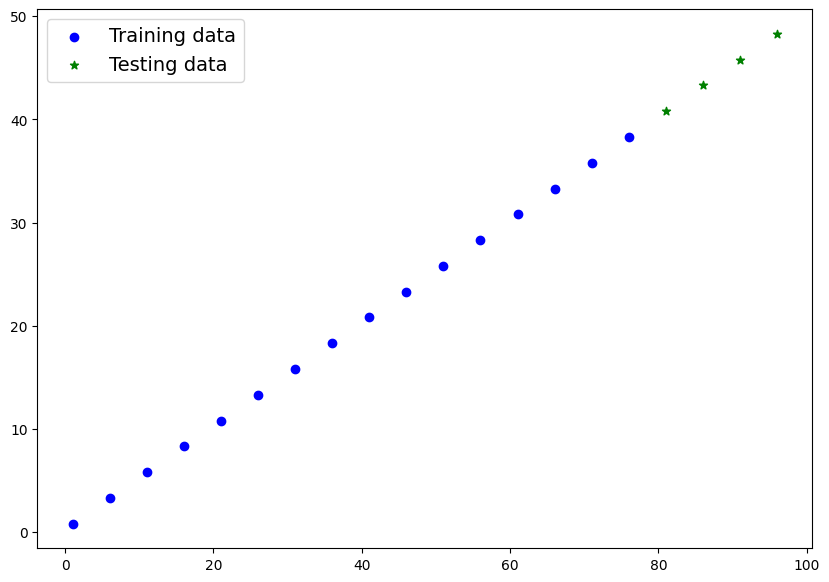

In [11]:
plot_predictions()

### Build Model 

In [12]:
# linear regression 
class LinearRegressionModel(nn.Module): 
    def __init__(self):
        super().__init__()
        
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
        
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
        
        # forward method 
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias
            
        
        

### Checking out the internals of our pytorch model (LinearRegressionModel())

In [13]:
# create random seed manually 
torch.manual_seed(42)

# create instance of model
model_0 = LinearRegressionModel()

# checkout parameters 
list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [14]:
# or to checkout parameters 
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions with our random model using inference model

In [ ]:
X_test, y_test

(tensor([[81],
         [86],
         [91],
         [96]]),
 tensor([[40.8000],
         [43.3000],
         [45.8000],
         [48.3000]]))

In [16]:
with torch.inference_mode():
    y_preds = model_0(X_test)
    
y_preds

tensor([[27.4007],
        [29.0842],
        [30.7676],
        [32.4511]])

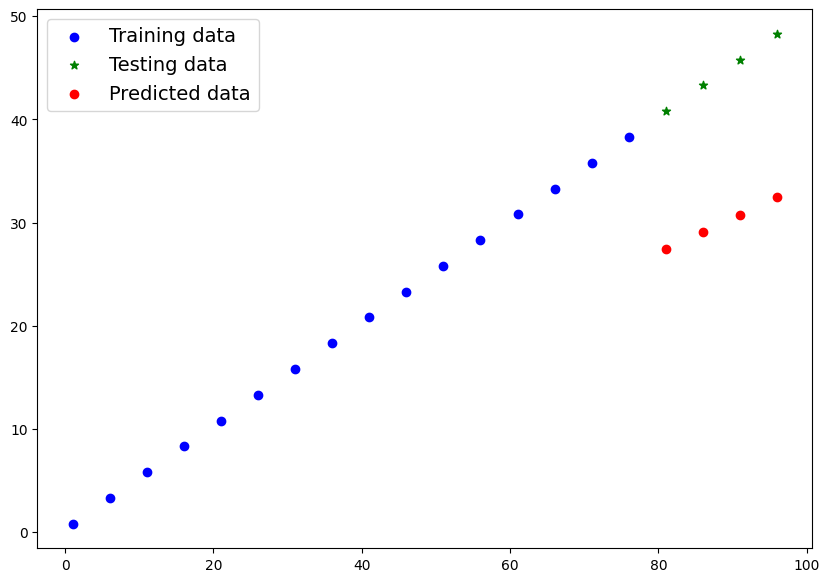

In [17]:
plot_predictions(prediction=y_preds)

### Loss and Optimizer 

In [18]:
# create loss function
loss_fn = torch.nn.L1Loss()

# create optimizer 
optimizer = torch.optim.SGD(params = model_0.parameters(), 
                        lr = 0.001)

### PYTORCH TRAINING LOOP

In [19]:
# epochs 
epochs = 200 

epoch_list = []
train_loss = []
test_loss = []

for epoch in range(epochs): 
    
    # put model into training 
    model_0.train()
    
    # forward pass 
    y_pred = model_0(X_train)
    
    # loss 
    loss = loss_fn(y_pred, y_train)
    
    # optimizer zero gradient  
    optimizer.zero_grad()
    
    # back prop 
    loss.backward()
    
    # perform gradient descent 
    optimizer.step()
    
    # turnoff gradient tracking 
    model_0.eval()
    
    # Testing 
    with torch.inference_mode():
        
        # forward pass 
        y_pred_test = model_0(X_test)
        
        # loss 
        y_test_loss = loss_fn(y_pred_test, y_test)
        
    if epoch%10 == 0:
        epoch_list.append(epoch)
        train_loss.append(loss)
        test_loss.append(y_test_loss)
        
        print(f"Epoch: {epoch}, Train Loss: {loss}, Test Loss: {y_test_loss}" )
        

Epoch: 0, Train Loss: 6.458611011505127, Test Loss: 11.215840339660645
Epoch: 10, Train Loss: 0.5107970237731934, Test Loss: 2.450725555419922
Epoch: 20, Train Loss: 0.48611098527908325, Test Loss: 2.506654739379883
Epoch: 30, Train Loss: 0.46142518520355225, Test Loss: 2.5625877380371094
Epoch: 40, Train Loss: 0.43673938512802124, Test Loss: 2.6185226440429688
Epoch: 50, Train Loss: 0.4120534062385559, Test Loss: 2.6744565963745117
Epoch: 60, Train Loss: 0.3873685896396637, Test Loss: 2.7303905487060547
Epoch: 70, Train Loss: 0.36268219351768494, Test Loss: 2.7863245010375977
Epoch: 80, Train Loss: 0.33799654245376587, Test Loss: 2.8422584533691406
Epoch: 90, Train Loss: 0.31331056356430054, Test Loss: 2.898188591003418
Epoch: 100, Train Loss: 0.2886248826980591, Test Loss: 2.9541234970092773
Epoch: 110, Train Loss: 0.26393890380859375, Test Loss: 3.010056495666504
Epoch: 120, Train Loss: 0.2392529994249344, Test Loss: 3.0659914016723633
Epoch: 130, Train Loss: 0.2145674228668213, Tes

In [20]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.4934])), ('bias', tensor([0.1449]))])

In [21]:
weight, bias

(0.5, 0.3)

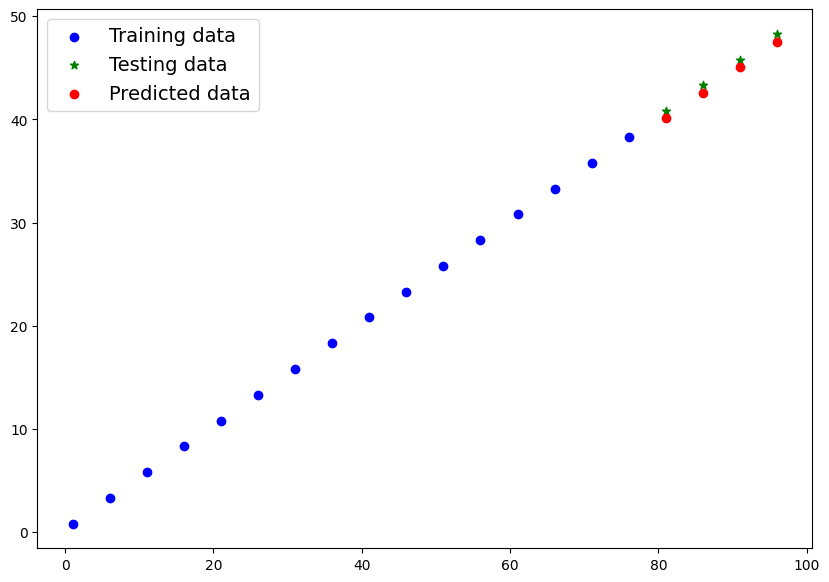

In [22]:
plot_predictions(prediction= y_pred_test.detach().numpy())

### Saving Model 

In [23]:
from pathlib import Path

# 1. Create models directory 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path 
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH) 

Saving model to: models/01_pytorch_workflow_model_0.pth


In [24]:
# Check the saved file path
!ls -l models/01_pytorch_workflow_model_0.pth

-rw-r--r-- 1 root root 2117 Feb 16 11:26 models/01_pytorch_workflow_model_0.pth


### Load Model

In [26]:
loaded_model = LinearRegressionModel()

loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [27]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.4934])), ('bias', tensor([0.1449]))])

In [28]:
loaded_model.state_dict()

OrderedDict([('weights', tensor([0.4934])), ('bias', tensor([0.1449]))])

In [29]:
# Make prediction using loaded model 
loaded_model.eval()

with torch.inference_mode():
    loaded_model_pred = loaded_model(X_test)
    
loaded_model_pred

tensor([[40.1135],
        [42.5807],
        [45.0479],
        [47.5151]])

In [30]:
# Make prediction using old built model_0 
model_0.eval()

with torch.inference_mode():
    pred = model_0(X_test)
    
pred

tensor([[40.1135],
        [42.5807],
        [45.0479],
        [47.5151]])

In [31]:
pred == loaded_model_pred

tensor([[True],
        [True],
        [True],
        [True]])

# PUTTING ALL TOGETHER 

### 1.1 Importing Libraries 

### 1.2 Data and Visualization

### 1.3 Creating Model  

### 1.4 Training And Testing model 

### 1.5 Making Prediction

### 1.6 Saving And Loading Model